In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_excel("SecDep_claims_data.xlsx", sheet_name="Security Deposit Claims")

In [3]:
df.head()

,Tracking Number,Claim Date,Approval Date,Lease Street Address,Lease City,Lease State,Lease Zip,Lease Start Date,Lease End Date,Move-Out Date,...,Collected Amount,Collection Processed Date,Review Claim Adjudication,Review Tenant Information,Update YRIG Policy Info,Open Collections,View PM Information,PM Notification of Claim Received,Send to Collections,Audit Selection
0,1246,2025-04-04,NaT,3121 LILY WAY,KENNESAW,GA,30144,2024-03-22 00:00:00,2025-03-31,2025-03-14,...,NaN,NaT,No,Yes,Yes,No,No,1.0,NaN,NaN
1,1245,2025-04-04,NaT,143 Weston Watch Road,Irmo,SC,29063,2023-04-03 00:00:00,2025-05-01,2025-01-31,...,NaN,NaT,No,Yes,Yes,Yes,No,1.0,NaN,NaN
2,1244,2025-04-04,2025-04-04,16427 Kentucky Ridge,San Antonio,Texas,78154,2024-04-26 00:00:00,2025-04-30,2025-03-31,...,NaN,NaT,No,Yes,Yes,Yes,No,1.0,NaN,NaN
3,1243,2025-04-04,NaT,20828 SW Peacock Dr,Dunnellon,Florida,34431,2024-03-21 00:00:00,2025-03-23,2025-03-23,...,NaN,NaT,No,Yes,Yes,Yes,No,1.0,NaN,NaN
4,1242,2025-04-04,NaT,"46 Crossing Street Ste F, F-46",Powell,OH,43065,2024-03-02 00:00:00,2025-03-01,2025-03-01,...,NaN,NaT,No,Yes,Yes,Yes,No,1.0,NaN,NaN


In [4]:
print(df.columns)

Index(['Tracking Number', 'Claim Date', 'Approval Date',
       'Lease Street Address', 'Lease City', 'Lease State', 'Lease Zip',
       'Lease Start Date', 'Lease End Date', 'Move-Out Date', 'Monthly Rent',
       'Amount of Claim', 'Termination Type', 'Tenant Contacted',
       'Tenant Collection Status', 'Collection Status',
       'Primary Tenant Employer Name', 'Is there a 2nd Tenant?',
       '#2 Relationship', '#2 Tenant Employer Name',
       '#2 Tenant Employer Phone #', 'Is there a 3rd Tenant?',
       'Property Management Company', 'Property Manager Name', 'Group #',
       'Treaty #', 'Policy', 'Max Benefit', 'Status', 'Pending Docs from PM',
       'Approved Benefit Amount', 'PM Explanation', 'Hold Reason',
       'Posted Date', 'Agreed Tenant Settlement',
       'Agreed Tenant Settlement Date', 'Collected Date', 'Collected Amount',
       'Collection Processed Date', 'Review Claim Adjudication',
       'Review Tenant Information', 'Update YRIG Policy Info',
       'Open C

In [84]:
import pandas as pd

date_columns = [
    'Lease Start Date', 'Lease End Date', 'Move-Out Date',
    'Claim Date', 'Approval Date',
    'Collected Date', 'Posted Date'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df['lease_duration_days'] = (
    (df['Lease End Date'] - df['Lease Start Date']).dt.days
)
df.loc[df['lease_duration_days'] < 0, 'lease_duration_days'] = pd.NA

df['days_to_claim'] = (df['Claim Date'] - df['Move-Out Date']).dt.days
df.loc[df['days_to_claim'] < 0, 'days_to_claim'] = pd.NA

df['days_to_approval'] = (df['Approval Date'] - df['Claim Date']).dt.days

# df['days_to_settlement'] = (df['Agreed Tenant Settlement Date'] - df['Claim Date']).dt.days
# df['days_to_collection'] = (df['Collected Date'] - df['Move-Out Date']).dt.days

df['claim_processing_days'] = (df['Posted Date'] - df['Approval Date']).dt.days
df.loc[df['claim_processing_days'] < 0, 'claim_processing_days'] = pd.NA

df['is_claim_late'] = df['days_to_claim'] > 30
df['claim_month'] = df['Claim Date'].dt.month
df['claim_weekday'] = df['Claim Date'].dt.day_name()

columns_to_show = date_columns + [
    'lease_duration_days', 'days_to_claim', 'days_to_approval',
    'claim_processing_days',
    'is_claim_late', 'claim_month', 'claim_weekday'
]

In [85]:
df[columns_to_show].head()

,Lease Start Date,Lease End Date,Move-Out Date,Claim Date,Approval Date,Collected Date,Posted Date,lease_duration_days,days_to_claim,days_to_approval,claim_processing_days,is_claim_late,claim_month,claim_weekday
0,2024-03-22,2025-03-31,2025-03-14,2025-04-04,NaT,NaT,NaT,374.0,21.0,NaN,NaN,False,4,Friday
1,2023-04-03,2025-05-01,2025-01-31,2025-04-04,NaT,NaT,NaT,759.0,63.0,NaN,NaN,True,4,Friday
2,2024-04-26,2025-04-30,2025-03-31,2025-04-04,2025-04-04,NaT,NaT,369.0,4.0,0.0,NaN,False,4,Friday
3,2024-03-21,2025-03-23,2025-03-23,2025-04-04,NaT,NaT,NaT,367.0,12.0,NaN,NaN,False,4,Friday
4,2024-03-02,2025-03-01,2025-03-01,2025-04-04,NaT,NaT,NaT,364.0,34.0,NaN,NaN,True,4,Friday


In [86]:
engineered_cols = [
    'lease_duration_days', 'days_to_claim', 'days_to_approval','claim_processing_days',
    'is_claim_late', 'claim_month', 'claim_weekday'
]

total_rows = df.shape[0]
rows_with_complete_engineered_data = df[engineered_cols].dropna().shape[0]
rows_with_missing_engineered_data = total_rows - rows_with_complete_engineered_data
print(f"Total rows: {total_rows}")
print(f"Rows with complete engineered data: {rows_with_complete_engineered_data}")
print(f"Rows with missing engineered values: {rows_with_missing_engineered_data}")

Total rows: 1244
Rows with complete engineered data: 867
Rows with missing engineered values: 377


In [87]:
print("Approval date -",df['Approval Date'].isna().sum())
print("Agreed Tenant Settlement Date -",df['Agreed Tenant Settlement Date'].isna().sum())
print("Collected Date -",df['Collected Date'].isna().sum())
print("Posted Date -",df['Posted Date'].isna().sum())
print("Lease Start Date -",df['Lease Start Date'].isna().sum())
print("Lease End Date -",df['Lease End Date'].isna().sum())
print("Move-Out Date -",df['Move-Out Date'].isna().sum())
print("Claim Date -",df['Claim Date'].isna().sum())

print("Approval and Posted Date commons - ",df[df['Approval Date'].isna() & df['Posted Date'].isna()].shape[0])

Approval date - 174
Agreed Tenant Settlement Date - 1044
Collected Date - 1063
Posted Date - 138
Lease Start Date - 8
Lease End Date - 245
Move-Out Date - 7
Claim Date - 0
Approval and Posted Date commons -  124


In [88]:
print("Lease Duration Days -",df['lease_duration_days'].isna().sum())
print("Claim processing time -",df['claim_processing_days'].isna().sum())
print("Days to Approval -",df['days_to_approval'].isna().sum())
print("Days to Claim -",df['days_to_claim'].isna().sum())
print("Is the claim late -",df['is_claim_late'].isna().sum())
print("Claiming Month -",df['claim_month'].isna().sum())
print("Claiming Week day -",df['claim_weekday'].isna().sum())

#highest Nan values are from lease duration days, days to approval, claiming processing time - 
print("Lease Duration, Claiming Processing Time & Days to Approval Common - ",df[df['lease_duration_days'].isna() & df['claim_processing_days'].isna() & df['days_to_approval'].isna()].shape[0])
print("Lease Duration & Claiming Processing Time - ",df[df['lease_duration_days'].isna() & df['claim_processing_days'].isna()].shape[0])
print("Lease Duration & Days to Approval Common - ",df[df['lease_duration_days'].isna() & df['days_to_approval'].isna()].shape[0])
print("Claiming Processing Time & Days to Approval Common - ",df[df['claim_processing_days'].isna() & df['days_to_approval'].isna()].shape[0])

Lease Duration Days - 252
Claim processing time - 191
Days to Approval - 174
Days to Claim - 17
Is the claim late - 0
Claiming Month - 0
Claiming Week day - 0
Lease Duration, Claiming Processing Time & Days to Approval Common -  70
Lease Duration & Claiming Processing Time -  71
Lease Duration & Days to Approval Common -  70
Claiming Processing Time & Days to Approval Common -  174


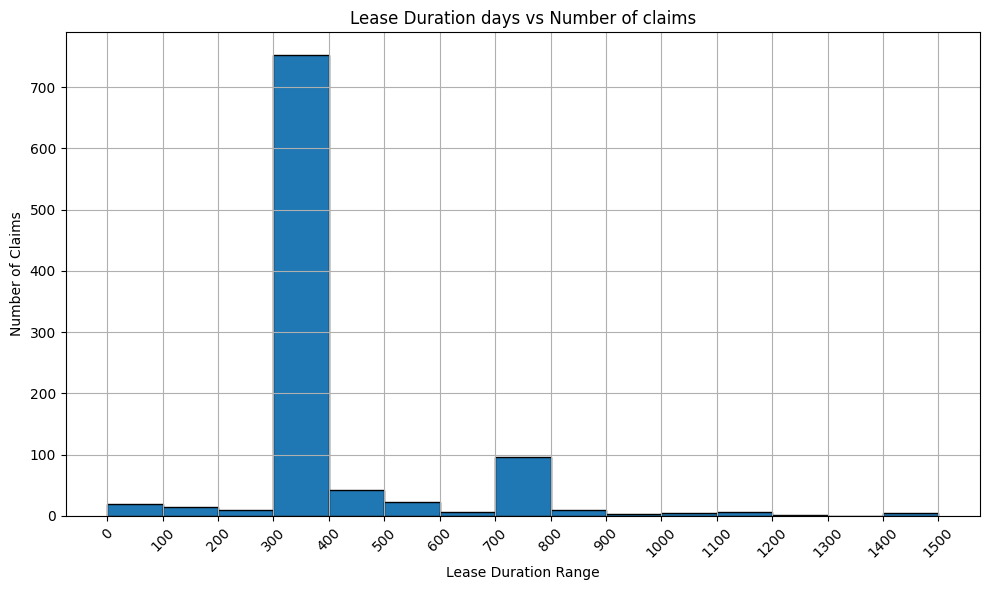

In [89]:
import matplotlib.pyplot as plt

lease_duration = df['lease_duration_days'].dropna()

bins = list(range(0, 1600, 100))
plt.figure(figsize=(10, 6))
plt.hist(lease_duration, bins=bins, edgecolor='black')

plt.title("Lease Duration days vs Number of claims")
plt.xlabel("Lease Duration Range")
plt.ylabel("Number of Claims")
plt.xticks(bins, rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


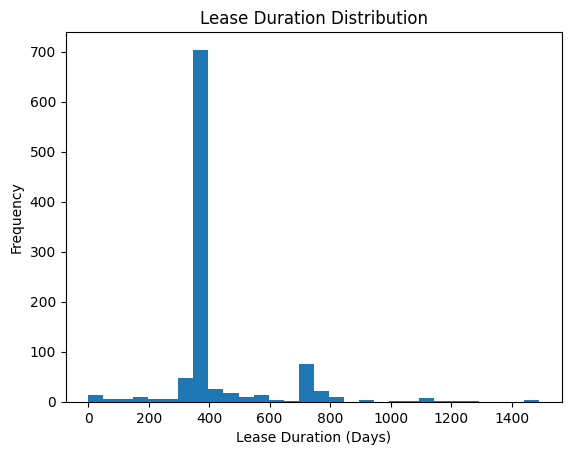

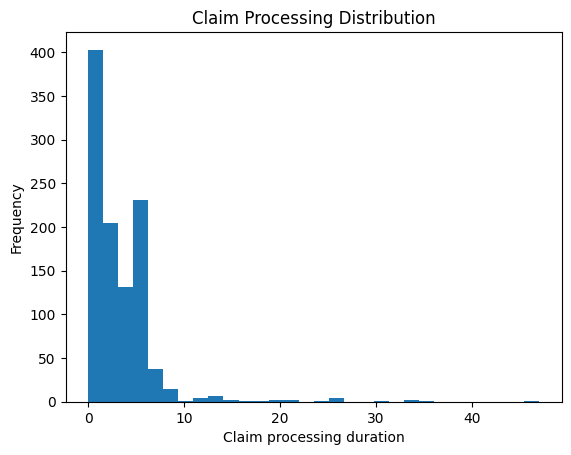

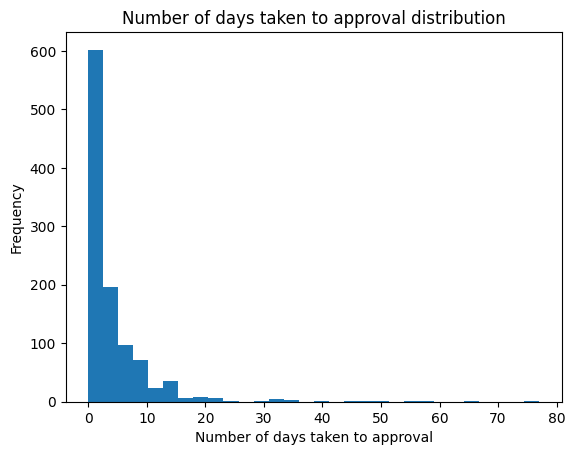

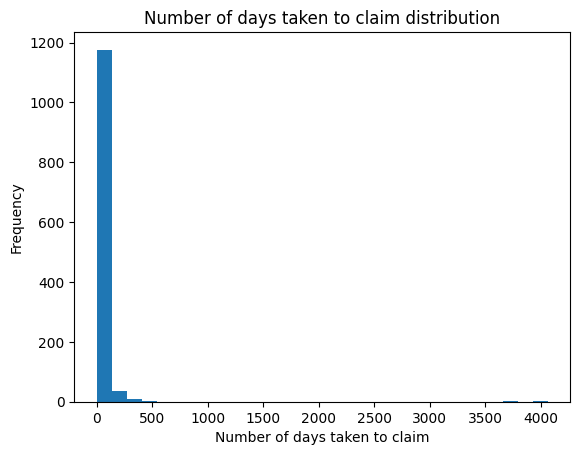

In [90]:
plt.hist(df['lease_duration_days'].dropna(), bins=30)
plt.title("Lease Duration Distribution")
plt.xlabel("Lease Duration (Days)")
plt.ylabel("Frequency")
plt.show()

plt.hist(df['claim_processing_days'].dropna(), bins=30)
plt.title("Claim Processing Distribution")
plt.xlabel("Claim processing duration")
plt.ylabel("Frequency")
plt.show()

plt.hist(df['days_to_approval'].dropna(), bins=30)
plt.title("Number of days taken to approval distribution")
plt.xlabel("Number of days taken to approval")
plt.ylabel("Frequency")
plt.show()

plt.hist(df['days_to_claim'].dropna(), bins=30)
plt.title("Number of days taken to claim distribution")
plt.xlabel("Number of days taken to claim")
plt.ylabel("Frequency")
plt.show()


/var/folders/s_/vq0w0h3d2qs1dfkr3j47mzfm0000gn/T/ipykernel_9012/3165587803.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('lease_bin')['claim_processing_days'].mean().dropna()


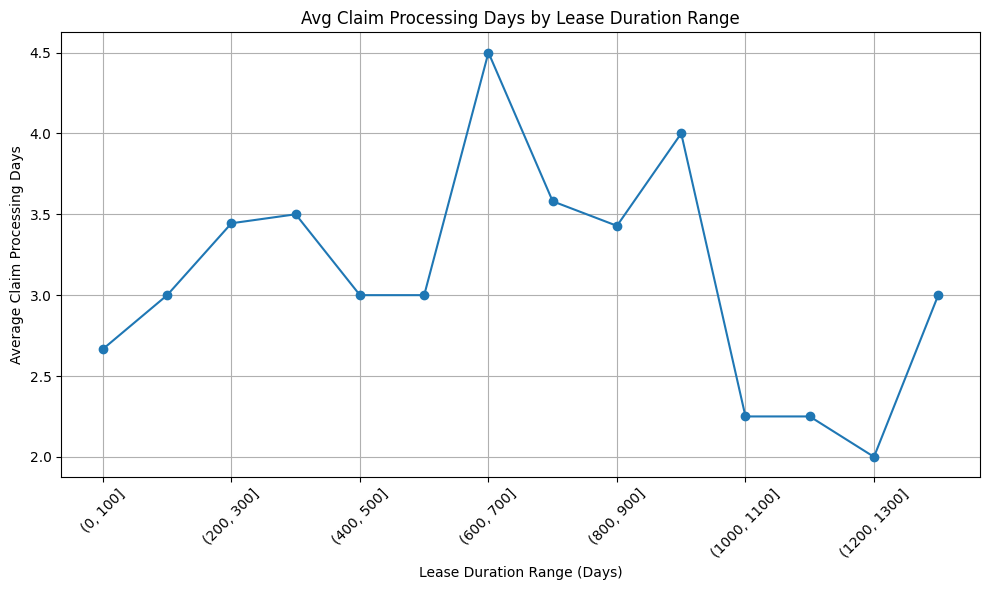

In [91]:
# Create bins for lease duration
df['lease_bin'] = pd.cut(df['lease_duration_days'], bins=range(0, 1600, 100))

# Group and calculate mean claim processing time
grouped = df.groupby('lease_bin')['claim_processing_days'].mean().dropna()

# Plot as line
plt.figure(figsize=(10, 6))
grouped.plot(marker='o')

plt.title("Avg Claim Processing Days by Lease Duration Range")
plt.xlabel("Lease Duration Range (Days)")
plt.ylabel("Average Claim Processing Days")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


/var/folders/s_/vq0w0h3d2qs1dfkr3j47mzfm0000gn/T/ipykernel_9012/3791226713.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('lease_bin')['claim_processing_days'].mean().dropna()


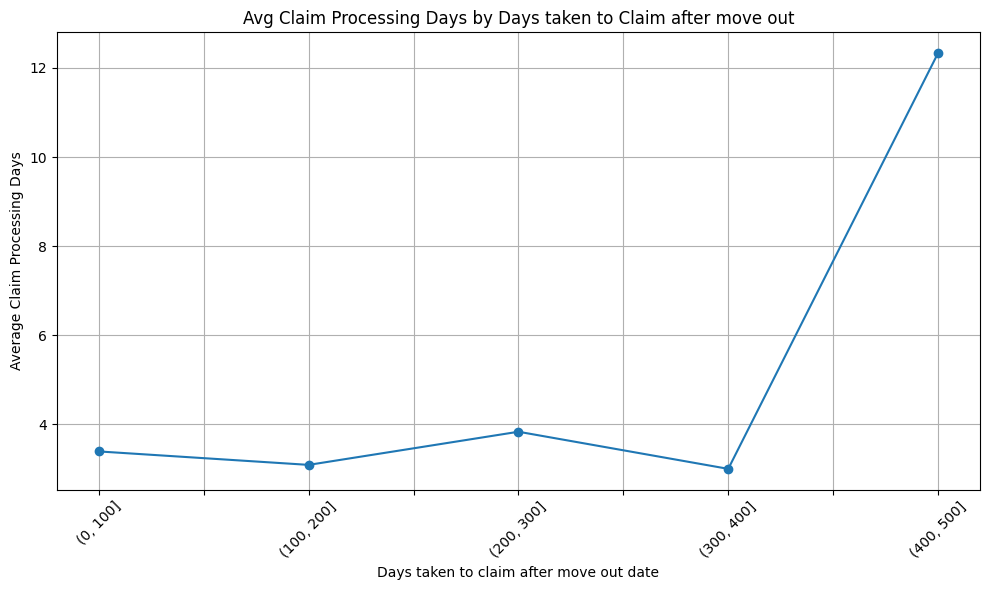

In [94]:
df['lease_bin'] = pd.cut(df['days_to_claim'], bins=range(0, 700, 100))
grouped = df.groupby('lease_bin')['claim_processing_days'].mean().dropna()
plt.figure(figsize=(10, 6))
grouped.plot(marker='o')
plt.title("Avg Claim Processing Days by Days taken to Claim after move out")
plt.xlabel("Days taken to claim after move out date")
plt.ylabel("Average Claim Processing Days")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


/var/folders/s_/vq0w0h3d2qs1dfkr3j47mzfm0000gn/T/ipykernel_9012/619153058.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('lease_bin')['days_to_approval'].mean().dropna()


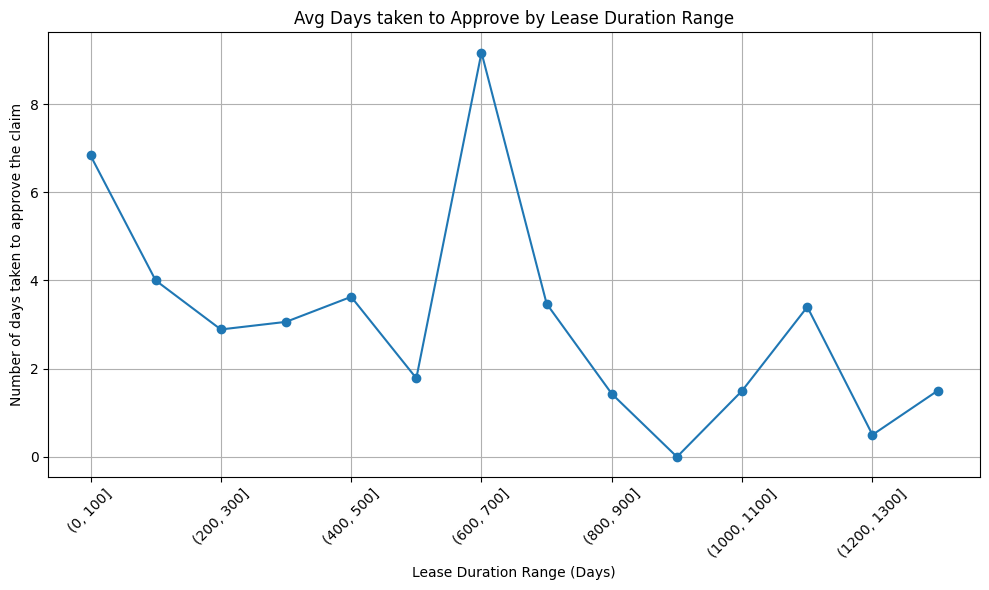

In [95]:
df['lease_bin'] = pd.cut(df['lease_duration_days'], bins=range(0, 1600, 100))
grouped = df.groupby('lease_bin')['days_to_approval'].mean().dropna()
plt.figure(figsize=(10, 6))
grouped.plot(marker='o')
plt.title("Avg Days taken to Approve by Lease Duration Range")
plt.xlabel("Lease Duration Range (Days)")
plt.ylabel("Number of days taken to approve the claim")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


/var/folders/s_/vq0w0h3d2qs1dfkr3j47mzfm0000gn/T/ipykernel_9012/619153058.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('lease_bin')['days_to_approval'].mean().dropna()


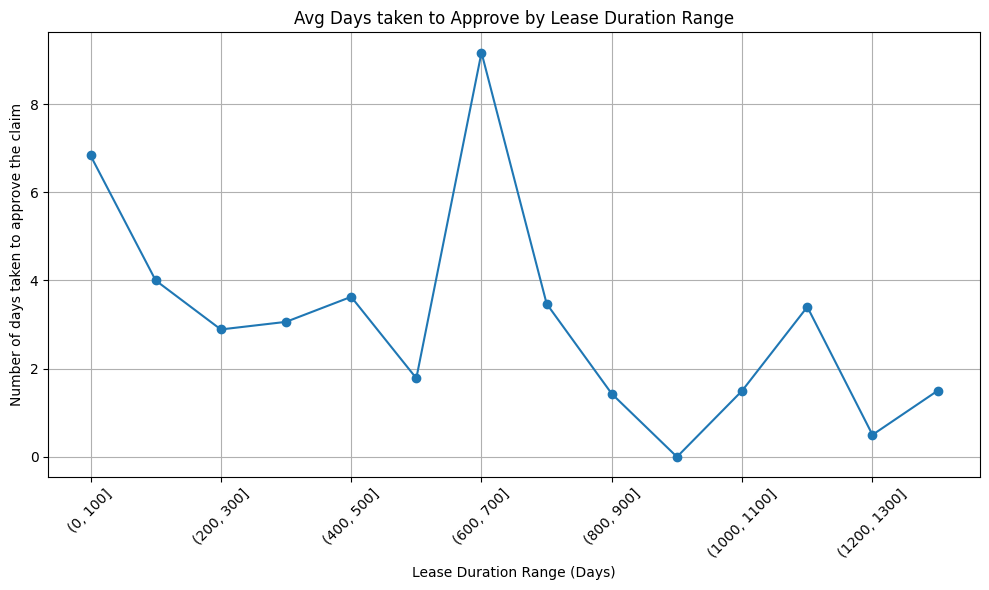

In [97]:
df['lease_bin'] = pd.cut(df['lease_duration_days'], bins=range(0, 1600, 100))
grouped = df.groupby('lease_bin')['days_to_approval'].mean().dropna()
plt.figure(figsize=(10, 6))
grouped.plot(marker='o')
plt.title("Avg Days taken to Approve by Lease Duration Range")
plt.xlabel("Lease Duration Range (Days)")
plt.ylabel("Number of days taken to approve the claim")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


/var/folders/s_/vq0w0h3d2qs1dfkr3j47mzfm0000gn/T/ipykernel_9012/2978842258.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped1 = df.groupby('lease_bin_1')['claim_processing_days'].mean().dropna()
/var/folders/s_/vq0w0h3d2qs1dfkr3j47mzfm0000gn/T/ipykernel_9012/2978842258.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped2 = df.groupby('lease_bin_2')['claim_processing_days'].mean().dropna()
/var/folders/s_/vq0w0h3d2qs1dfkr3j47mzfm0000gn/T/ipykernel_9012/2978842258.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass 

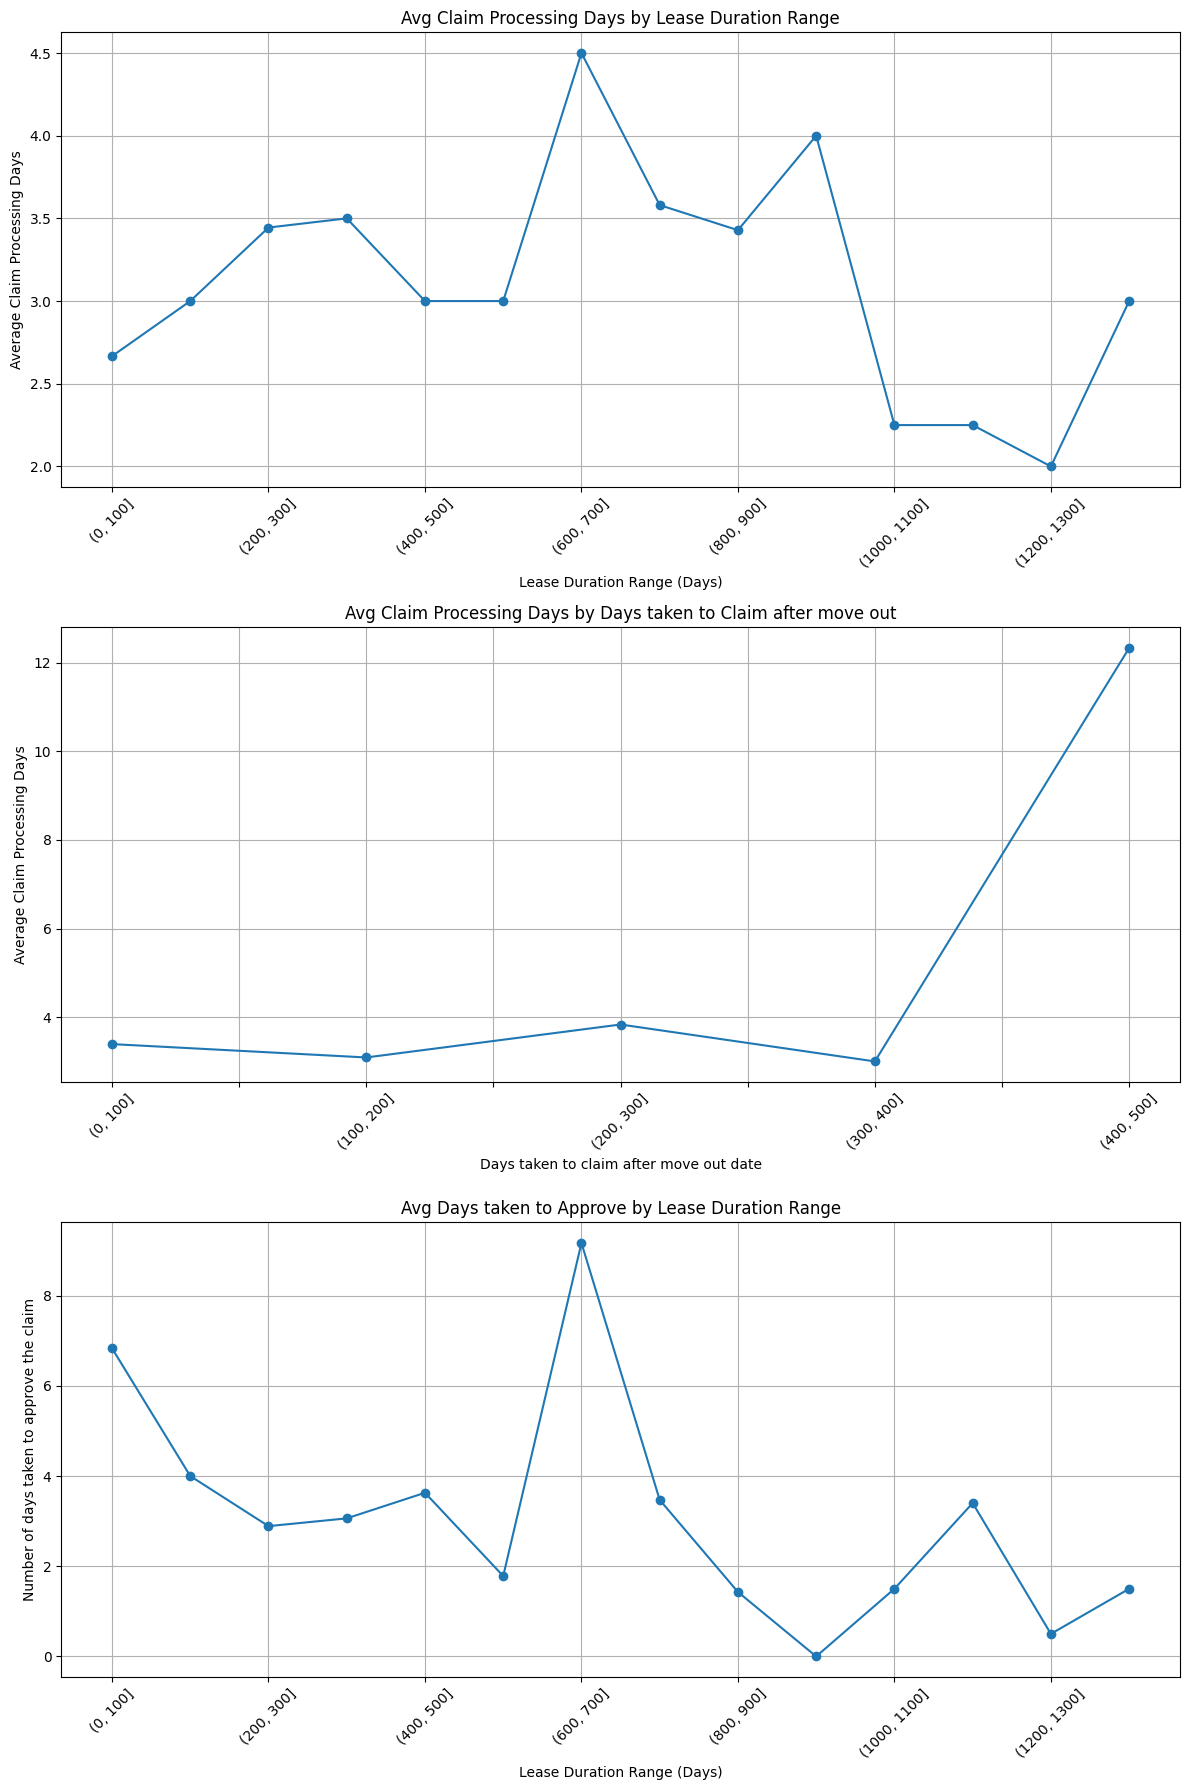

In [96]:
import matplotlib.pyplot as plt
import pandas as pd

# First binning and grouping
df['lease_bin_1'] = pd.cut(df['lease_duration_days'], bins=range(0, 1600, 100))
grouped1 = df.groupby('lease_bin_1')['claim_processing_days'].mean().dropna()

# Second binning and grouping
df['lease_bin_2'] = pd.cut(df['days_to_claim'], bins=range(0, 700, 100))
grouped2 = df.groupby('lease_bin_2')['claim_processing_days'].mean().dropna()

# Third binning and grouping
df['lease_bin_3'] = pd.cut(df['lease_duration_days'], bins=range(0, 1600, 100))
grouped3 = df.groupby('lease_bin_3')['days_to_approval'].mean().dropna()

# Create subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Plot 1
grouped1.plot(ax=axes[0], marker='o')
axes[0].set_title("Avg Claim Processing Days by Lease Duration Range")
axes[0].set_xlabel("Lease Duration Range (Days)")
axes[0].set_ylabel("Average Claim Processing Days")
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True)

# Plot 2
grouped2.plot(ax=axes[1], marker='o')
axes[1].set_title("Avg Claim Processing Days by Days taken to Claim after move out")
axes[1].set_xlabel("Days taken to claim after move out date")
axes[1].set_ylabel("Average Claim Processing Days")
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True)

# Plot 3
grouped3.plot(ax=axes[2], marker='o')
axes[2].set_title("Avg Days taken to Approve by Lease Duration Range")
axes[2].set_xlabel("Lease Duration Range (Days)")
axes[2].set_ylabel("Number of days taken to approve the claim")
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True)

# Adjust layout
plt.tight_layout()
plt.show()
